# Fake Review Detection in Online Restaurant Reviews Using Machine Learning and Reviewer Behaviour Analytics
**Fraud Detection Analytics (FDA) project**

## Business problem
Fake and incentivised reviews mislead customers and distort restaurant ratings. A review platform cannot check every review by hand. **Goal:** build a machine-learning model that scores each review for how suspicious it is, so human moderators can check the riskiest ones first.

## Data
Real Yelp restaurant reviews (not synthetic), pre-split into **train (9,929)** and **test (2,483)** reviews. Target `flagged`: 1 = filtered by Yelp as suspicious/fake, 0 = genuine.

## Approach (classic machine learning on structured data)
The model learns from **numbers about the review and the reviewer** (rating, account age, friends, number of reviews, votes, ...). No text/NLP techniques are used.

1. Load and check the data (incl. leakage)  2. Explore  3. Build features  4. Find out which information detects fakes (ablation)  5. Compare models  6. Tune the best one  7. Evaluate on the untouched test set  8. Explain the model  9. Business use and limitations

In [1]:
import os, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_predict, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, classification_report)

try:                                   # nicer tables inside Jupyter; plain print elsewhere
    from IPython.display import display
except ImportError:
    display = print

os.makedirs("images", exist_ok=True)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
SEED = 42

## 1. Load data

In [2]:
def find_file(name):
    # works whether the CSVs are in ./data/ or in the same folder as this file
    for folder in ["data", ".", "../data"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Could not find {name}. Put it in a folder called 'data' next to this notebook.")

train = pd.read_csv(find_file("yelp_train.csv"), encoding="utf-8-sig")
test  = pd.read_csv(find_file("yelp_test.csv"),  encoding="utf-8-sig")
print("train:", train.shape, "| test:", test.shape)
display(train.drop(columns="reviewContent").head(3))

train: (9929, 22) | test: (2483, 22)


,reviewID,reviewerID,restaurantID,date,rating,reviewUsefulCount,flagged,name,location,yelpJoinDate,...,reviewCount,firstCount,usefulCount,coolCount,funnyCount,complimentCount,tipCount,fanCount,restaurantRating,ReviewLength
0,Z_wgGcI8_Txo87Wz7CxdrQ,cM9GIlk61Qh2thLyJyxNyA,N7juvW8YoFIj7sEBzVF8GQ,9/17/2010,5,0,1,suzie n.,"Los Angeles, CA",July 2009,...,1,0,1,2,0,0,0,0,4.0,144
1,NJfQb03MSstqYagt860Oaw,SVlSPBnjCzY2Bu9n8y2C5A,o54U2VkQama8FI30qDkWvw,1/31/2008,5,0,0,Jacqui B.,"Kalamazoo, MI",January 2008,...,12,2,19,7,6,4,0,0,4.0,46
2,2uao3bK9iSV4fuMwuSYCiQ,5HYWhPS3ozYifieW0lWMUw,1QKqtC4vML3QhkrSzwR_tQ,3/31/2010,5,0,1,Mike A.,"Los Angeles, CA",March 2010,...,6,0,7,3,2,0,0,0,3.5,18


**Columns in plain words:** `rating` = stars given; `restaurantRating` = the restaurant's average stars; `ReviewLength` = number of words in the review; reviewer profile counts (`friendCount`, `reviewCount`, `firstCount`, `usefulCount`, `coolCount`, `funnyCount`, `complimentCount`, `tipCount`, `fanCount`); `yelpJoinDate` = when the reviewer joined; `flagged` = **target**.

The review text column (`reviewContent`) is **not used**: this project uses structured data only.

## 2. Data quality and leakage checks

In [3]:
print("Missing values (train):", train.drop(columns="reviewContent").isna().sum()[lambda s: s > 0].to_dict())
print("Missing values (test) :", test.drop(columns="reviewContent").isna().sum()[lambda s: s > 0].to_dict())
print("Duplicate review IDs:", train.reviewID.duplicated().sum())
print("Review IDs in both train and test:", len(set(train.reviewID) & set(test.reviewID)))
print("Reviewers in both train and test:", len(set(train.reviewerID) & set(test.reviewerID)))
print("Restaurants in train / test:", train.restaurantID.nunique(), "/", test.restaurantID.nunique())
print("Share flagged  train: %.3f  test: %.3f" % (train.flagged.mean(), test.flagged.mean()))

Missing values (train): {'location': 1}
Missing values (test) : {'location': 2}
Duplicate review IDs: 0
Review IDs in both train and test: 0
Reviewers in both train and test: 553
Restaurants in train / test: 104 / 99
Share flagged  train: 0.497  test: 0.512


In [4]:
# Leakage check: does any column give the answer away?
print("Share of reviews with reviewUsefulCount == 0:")
display(train.groupby("flagged").reviewUsefulCount.apply(lambda s: (s == 0).mean()).rename({0: "genuine", 1: "flagged"}).round(3))

Share of reviews with reviewUsefulCount == 0:


flagged
genuine    0.583
flagged    1.000
Name: reviewUsefulCount, dtype: float64

**What I found**
* Almost no missing data; no duplicate IDs; no review appears in both train and test.
* **Leakage:** `reviewUsefulCount` is 0 for **100%** of flagged reviews. Yelp hides filtered reviews, so they never receive votes. It also grows only *after* a review is posted, so it would not be known at detection time. **I exclude it** and measure its effect in the ablation.
* The classes are ~50/50. The dataset was sampled this way; on a real platform fake reviews are rarer. Section 10 shows what that does to precision.
* **Reviewer overlap:** some reviewers appear in both train and test. To keep model comparison honest, all cross-validation keeps each reviewer's reviews together in one fold (`GroupKFold`).

## 3. Exploratory data analysis

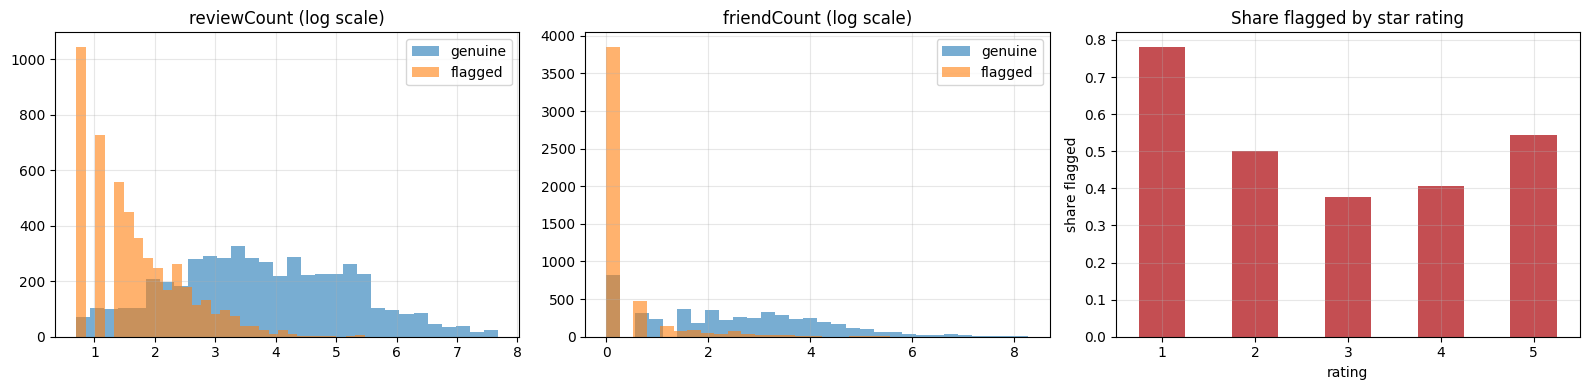

,reviewCount,friendCount,fanCount,usefulCount,ReviewLength
flagged,,,,,
genuine,39.5,11.0,1.0,33.0,68.0
flagged,4.0,0.0,0.0,1.0,44.0


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, col in zip(ax[:2], ["reviewCount", "friendCount"]):
    for lab, name in [(0, "genuine"), (1, "flagged")]:
        a.hist(np.log1p(train.loc[train.flagged == lab, col]), bins=30, alpha=.6, label=name)
    a.set_title(f"{col} (log scale)"); a.legend()
train.groupby("rating").flagged.mean().plot.bar(ax=ax[2], color="#C44E52", rot=0)
ax[2].set_title("Share flagged by star rating"); ax[2].set_ylabel("share flagged")
plt.tight_layout(); plt.savefig("images/01_eda.png", dpi=150); plt.show()
display(train.groupby("flagged")[["reviewCount", "friendCount", "fanCount", "usefulCount", "ReviewLength"]].median().rename(index={0: "genuine", 1: "flagged"}))

**Takeaways**
* **Flagged reviews come from thin profiles:** fewer reviews, fewer friends, fewer votes. They look like new or one-off accounts.
* **Rating is U-shaped:** 1-star reviews are the most suspicious (about 78% flagged), 5-star next, 3-star the least.
* Flagged reviews are also **shorter** (median 44 vs 68 words).

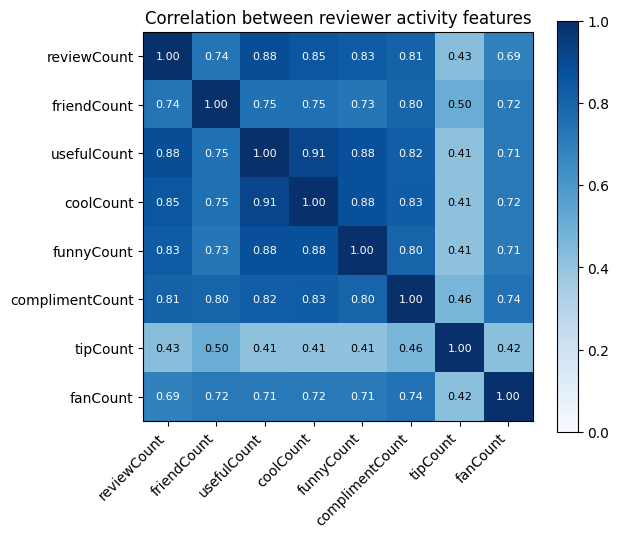

In [6]:
# Several reviewer columns measure the same thing ("how active is this reviewer?"). How correlated are they?
act = ["reviewCount", "friendCount", "usefulCount", "coolCount", "funnyCount", "complimentCount", "tipCount", "fanCount"]
corr = train[act].corr(method="spearman")
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(act))); ax.set_xticklabels(act, rotation=45, ha="right")
ax.set_yticks(range(len(act))); ax.set_yticklabels(act); ax.grid(False)
for i in range(len(act)):
    for j in range(len(act)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if corr.values[i, j] > 0.6 else "black")
plt.colorbar(im); plt.title("Correlation between reviewer activity features")
plt.tight_layout(); plt.savefig("images/02_correlation.png", dpi=150); plt.show()

These features are strongly correlated (median ~0.74, up to 0.91). This matters later: when several features carry the same information, their individual importance scores are shared between them.

## 4. Feature engineering
Two groups of features, all numeric:

| Group | Features | Why |
|---|---|---|
| **Review-level** | rating, restaurant rating, `rating_gap` (how far this rating is from the restaurant average), `extreme_rating` (1 or 5 stars), `ReviewLength` | fake reviews tend to be extreme, off-average and short |
| **Reviewer-level** | friends, reviews, votes, fans, tips, ..., `account_age_days` (account age when posting), `reviews_per_month`, `first_ratio` (share of reviews that were the first for a restaurant), `no_friends_no_fans` | fake accounts are new, thin and isolated |

In [7]:
def add_features(d):
    d = d.copy()
    # review-level
    d["rating_gap"] = (d["rating"] - d["restaurantRating"]).abs()
    d["extreme_rating"] = d["rating"].isin([1, 5]).astype(int)
    # reviewer-level
    d["account_age_days"] = (pd.to_datetime(d["date"]) - pd.to_datetime(d["yelpJoinDate"], format="%B %Y")).dt.days.clip(lower=0)
    d["reviews_per_month"] = d["reviewCount"] / (d["account_age_days"] / 30).clip(lower=1)
    d["first_ratio"] = d["firstCount"] / d["reviewCount"].clip(lower=1)
    d["no_friends_no_fans"] = ((d["friendCount"] == 0) & (d["fanCount"] == 0)).astype(int)
    return d

train, test = add_features(train), add_features(test)

REVIEW_FEATS = ["rating", "restaurantRating", "rating_gap", "extreme_rating", "ReviewLength"]
REVIEWER_FEATS = ["friendCount", "reviewCount", "firstCount", "usefulCount", "coolCount", "funnyCount",
                  "complimentCount", "tipCount", "fanCount", "account_age_days", "reviews_per_month",
                  "first_ratio", "no_friends_no_fans"]
FINAL_FEATS = REVIEW_FEATS + REVIEWER_FEATS

# store every model input as decimal numbers (some scikit-learn tools refuse integer columns)
for d in (train, test):
    d[FINAL_FEATS + ["reviewUsefulCount"]] = d[FINAL_FEATS + ["reviewUsefulCount"]].astype(float)

y_train, y_test, groups = train["flagged"], test["flagged"], train["reviewerID"]
cv = GroupKFold(n_splits=5)
print(len(REVIEW_FEATS), "review-level +", len(REVIEWER_FEATS), "reviewer-level features =", len(FINAL_FEATS))

5 review-level + 13 reviewer-level features = 18


## 5. Which information detects fakes? (feature-group ablation)
I train the same model on different feature groups to see what actually does the work. **CV AUC** is measured on training data (reviewer-grouped 5-fold); **Test AUC** is on the untouched test set. AUC is 0.5 for random guessing and 1.0 for a perfect model.

In [8]:
def make_gb(**kw):
    # Gradient Boosting: many small decision trees, each one correcting the mistakes of the previous ones
    params = dict(max_iter=300, max_depth=4, learning_rate=0.05, early_stopping=False, random_state=SEED)
    params.update(kw)
    return HistGradientBoostingClassifier(**params)

def cv_auc(model, cols):
    p = cross_val_predict(model, train[cols], y_train, cv=cv, groups=groups, method="predict_proba")[:, 1]
    return roc_auc_score(y_train, p)

sets = {
    "Review-level only":                 REVIEW_FEATS,
    "Reviewer profile only":             REVIEWER_FEATS,
    "Review + reviewer (FINAL)":         FINAL_FEATS,
    "FINAL + reviewUsefulCount (LEAKY)": FINAL_FEATS + ["reviewUsefulCount"],
}
rows = []
for name, cols in sets.items():
    m = make_gb().fit(train[cols], y_train)
    rows.append({"feature set": name, "CV AUC": cv_auc(make_gb(), cols),
                 "Test AUC": roc_auc_score(y_test, m.predict_proba(test[cols])[:, 1])})
ablation = pd.DataFrame(rows).set_index("feature set")
display(ablation.round(3))

,CV AUC,Test AUC
feature set,,
Review-level only,0.684,0.692
Reviewer profile only,0.935,0.935
Review + reviewer (FINAL),0.936,0.936
FINAL + reviewUsefulCount (LEAKY),0.950,0.950


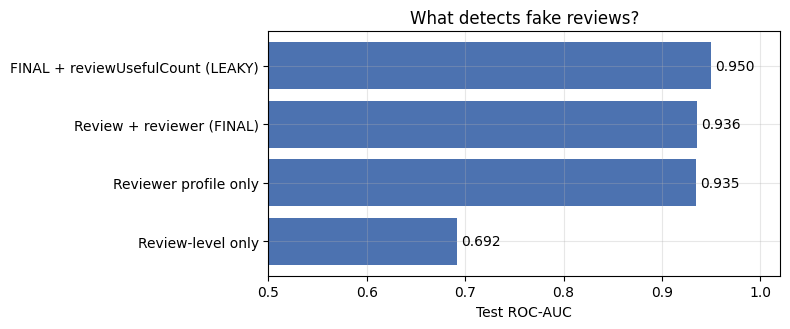

In [9]:
s = ablation["Test AUC"].sort_values()
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(s.index, s.values, color="#4C72B0")
for i, v in enumerate(s.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center")
ax.set_xlim(0.5, 1.02); ax.set_xlabel("Test ROC-AUC"); ax.set_title("What detects fake reviews?")
plt.tight_layout(); plt.savefig("images/03_ablation.png", dpi=150); plt.show()

**Reading the ablation (the main insight of the project)**
* **The reviewer profile alone is already very strong.** Who wrote the review matters most.
* **Review-level features alone are weak** but clearly better than random (0.5).
* Combining both is as good as the reviewer profile alone: the review-level features add little on top.
* The leaky `reviewUsefulCount` would add about 0.01 AUC. That gain would be fake, because the feature would not exist at detection time, so it stays out.

## 6. Model comparison
Same features, four different algorithms, compared with reviewer-grouped 5-fold CV and on the test set.

In [10]:
signed_log = lambda x: np.sign(np.asarray(x, float)) * np.log1p(np.abs(np.asarray(x, float)))

candidates = {
    "Logistic Regression": make_pipeline(FunctionTransformer(signed_log), StandardScaler(), LogisticRegression(max_iter=3000)),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=SEED, n_jobs=1),
    "Gradient Boosting":   make_gb(),
}

def metrics(y, p, thr=0.5):
    pred = (p >= thr).astype(int)
    return {"accuracy": accuracy_score(y, pred), "precision": precision_score(y, pred),
            "recall": recall_score(y, pred), "f1": f1_score(y, pred),
            "roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p)}

rows = []
for name, m in candidates.items():
    cvs = cv_auc(m, FINAL_FEATS)
    m.fit(train[FINAL_FEATS], y_train)
    rows.append({"model": name, "CV AUC": cvs, **metrics(y_test, m.predict_proba(test[FINAL_FEATS])[:, 1])})
comparison = pd.DataFrame(rows).set_index("model")
display(comparison.round(3))

,CV AUC,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Logistic Regression,0.934,0.863,0.848,0.893,0.870,0.932,0.920
Decision Tree,0.924,0.851,0.853,0.857,0.855,0.923,0.901
Random Forest,0.936,0.874,0.858,0.902,0.880,0.937,0.917
Gradient Boosting,0.936,0.868,0.850,0.901,0.875,0.936,0.921


* **Logistic Regression** is a simple straight-line-style model; **Decision Tree** is one set of if-then rules; **Random Forest** averages many trees; **Gradient Boosting** builds trees one after another, each fixing the previous mistakes.
* The models are close to each other. **The features matter more than the algorithm.** The single decision tree is the weakest (one tree is less stable than an ensemble).
* I carry **Gradient Boosting** forward: it is among the best by CV AUC and handles correlated, differently-scaled features without extra preparation. Logistic regression would be a legitimate, simpler choice in production.

## 7. Tune Gradient Boosting
A small grid search (12 settings), scored by reviewer-grouped CV AUC. The test set is **not** used for tuning.

In [11]:
grid = {"max_depth": [2, 3, 4], "max_iter": [200, 400], "learning_rate": [0.03, 0.08]}
search = GridSearchCV(make_gb(), grid, cv=cv, scoring="roc_auc", n_jobs=1)
search.fit(train[FINAL_FEATS], y_train, groups=groups)
print("Best settings:", search.best_params_)
print("Best CV AUC: %.4f   (untuned CV AUC: %.4f)" % (search.best_score_, comparison.loc["Gradient Boosting", "CV AUC"]))
final_model = search.best_estimator_

Best settings: {'learning_rate': 0.03, 'max_depth': 2, 'max_iter': 400}
Best CV AUC: 0.9384   (untuned CV AUC: 0.9362)


Tuning changes the result very little, which is typical when the features are doing the work. A shallow model is preferred: simpler and less likely to overfit.

## 8. Final evaluation on the test set

In [12]:
p_test = final_model.predict_proba(test[FINAL_FEATS])[:, 1]
pred = (p_test >= 0.5).astype(int)
print(classification_report(y_test, pred, target_names=["genuine", "fake"], digits=3))
final_scores = metrics(y_test, p_test)
print({k: round(v, 3) for k, v in final_scores.items()})

              precision    recall  f1-score   support

     genuine      0.882     0.835     0.858      1212
        fake      0.850     0.894     0.871      1271

    accuracy                          0.865      2483
   macro avg      0.866     0.864     0.865      2483
weighted avg      0.866     0.865     0.865      2483

{'accuracy': 0.865, 'precision': 0.85, 'recall': 0.894, 'f1': 0.871, 'roc_auc': 0.934, 'pr_auc': 0.921}


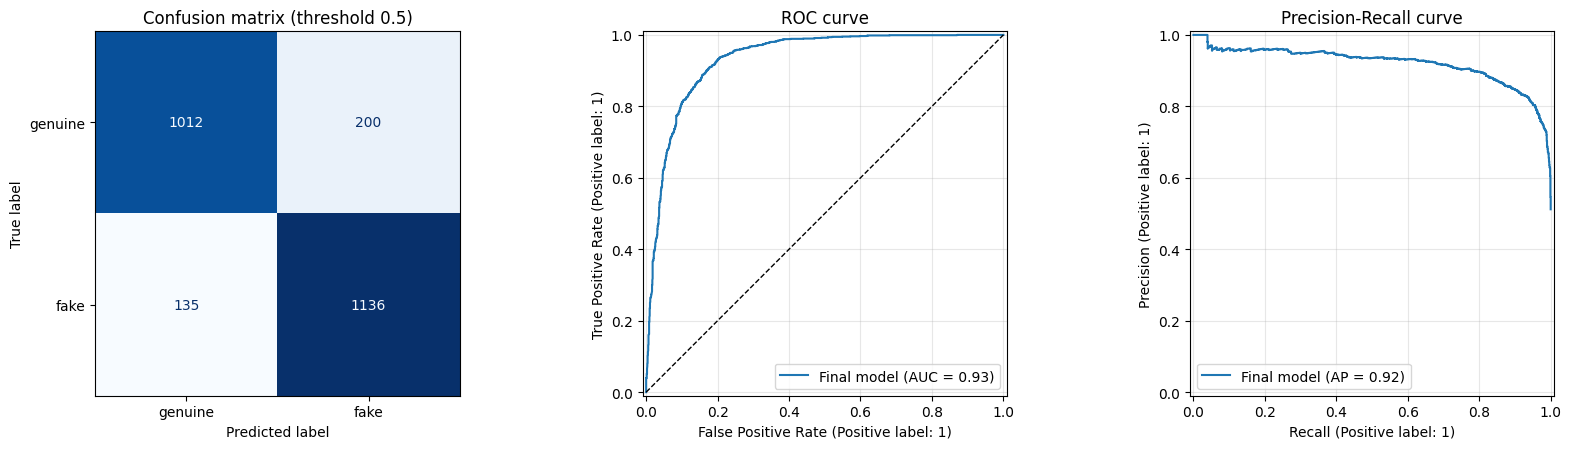

True fakes caught: 1136  | Fakes missed: 135  | Genuine wrongly flagged: 200  | Genuine correctly passed: 1012


In [13]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["genuine", "fake"], cmap="Blues", colorbar=False, ax=ax[0])
ax[0].set_title("Confusion matrix (threshold 0.5)"); ax[0].grid(False)
RocCurveDisplay.from_predictions(y_test, p_test, name="Final model", ax=ax[1])
ax[1].plot([0, 1], [0, 1], "k--", lw=1); ax[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, p_test, name="Final model", ax=ax[2]); ax[2].set_title("Precision-Recall curve")
plt.tight_layout(); plt.savefig("images/04_final_evaluation.png", dpi=150); plt.show()
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print(f"True fakes caught: {tp}  | Fakes missed: {fn}  | Genuine wrongly flagged: {fp}  | Genuine correctly passed: {tn}")

**Reading the results**
* **Recall** = share of real fakes the model catches. **Precision** = share of its "fake" calls that are truly flagged.
* The confusion matrix shows both kinds of error: fakes missed, and genuine reviews wrongly flagged.

### Choosing the threshold
The default cut-off is 0.5, but a platform can trade precision for recall. A lower cut-off catches more fakes but raises more false alarms.

In [14]:
rows = []
for thr in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    m = metrics(y_test, p_test, thr)
    rows.append({"threshold": thr, "precision": m["precision"], "recall": m["recall"], "f1": m["f1"]})
display(pd.DataFrame(rows).set_index("threshold").round(3))

,precision,recall,f1
threshold,,,
0.3,0.803,0.955,0.873
0.4,0.829,0.931,0.877
0.5,0.850,0.894,0.871
0.6,0.875,0.847,0.860
0.7,0.898,0.790,0.841
0.8,0.920,0.682,0.784


A strict platform (don't wrongly flag honest reviewers) would pick a high threshold; a platform that wants to catch as many fakes as possible would pick a lower one. 0.5 balances the two.

## 9. Where does the model struggle? (segment analysis)

,n,fake share,precision,recall
reviewer segment,,,,
1-2 reviews,493,0.923,0.934,0.996
3-10 reviews,779,0.747,0.824,0.950
>10 reviews,1211,0.193,0.722,0.556


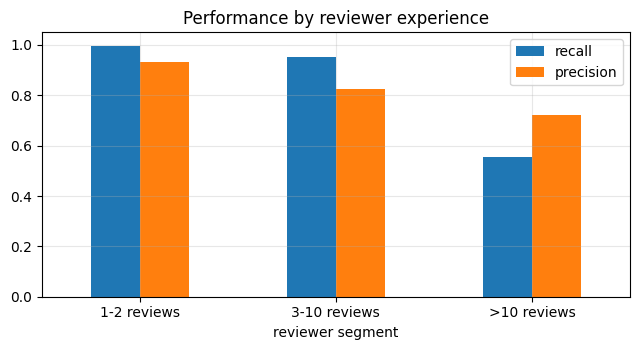

In [15]:
seg = pd.cut(test["reviewCount"], [0, 2, 10, np.inf], labels=["1-2 reviews", "3-10 reviews", ">10 reviews"])
rows = []
for s in seg.cat.categories:
    i = (seg == s).values
    m = metrics(y_test[i], p_test[i])
    rows.append({"reviewer segment": s, "n": int(i.sum()), "fake share": y_test[i].mean(), "precision": m["precision"], "recall": m["recall"]})
seg_df = pd.DataFrame(rows).set_index("reviewer segment")
display(seg_df.round(3))
ax = seg_df[["recall", "precision"]].plot.bar(rot=0, figsize=(6.5, 3.6)); ax.set_ylim(0, 1.05)
plt.title("Performance by reviewer experience"); plt.tight_layout(); plt.savefig("images/05_segments.png", dpi=150); plt.show()

**This is the model's main blind spot.** It catches almost every fake from new or low-activity accounts, but misses a large share of the flagged reviews from established reviewers (more than 10 reviews). A fake review from an aged, active account looks like a genuine one to a model that mostly reads reviewer profiles. This is a realistic limit, not a bug.

## 10. Would this work on a real platform?

In [16]:
# Precision depends on how common fakes are. Here the data is ~50% fake; real platforms have far fewer.
recall_ = recall_score(y_test, pred)
fpr_ = fp / (fp + tn)
prev = pd.DataFrame({"fake share of all reviews": [0.50, 0.20, 0.13, 0.05, 0.01]})
prev["expected precision"] = prev["fake share of all reviews"].apply(
    lambda s: recall_ * s / (recall_ * s + fpr_ * (1 - s)))
display(prev.round(3))

,fake share of all reviews,expected precision
0,0.50,0.844
1,0.20,0.575
2,0.13,0.447
3,0.05,0.222
4,0.01,0.052


With the same recall and false-alarm rate, precision drops quickly as fakes get rarer. **So this should be used as a ranking tool for human moderators, not as an automatic deletion system.** Moderators would review the highest-scoring reviews first:

In [17]:
order = np.argsort(-p_test)
rows = []
for k in [0.05, 0.10, 0.20, 0.30]:
    n = int(len(order) * k)
    top = y_test.values[order[:n]]
    rows.append({"moderators review top": f"{int(k*100)}% of reviews", "reviews": n, "share truly flagged": top.mean()})
display(pd.DataFrame(rows).set_index("moderators review top").round(3))

,reviews,share truly flagged
moderators review top,,
5% of reviews,124,0.960
10% of reviews,248,0.960
20% of reviews,496,0.950
30% of reviews,744,0.934


If moderators can only check the 10% highest-scoring reviews, nearly all of them are real catches (on this ~50% fake sample; on a real platform the share would be lower). That is the practical value of the model.

## 11. Explaining the model
Two simple, standard tools:
* **Permutation importance:** shuffle one feature at a time and see how much the test AUC drops. A bigger drop = the model relies on that feature more.
* **Partial dependence:** how the model's fake score changes as one feature goes from low to high (higher score = more likely fake).

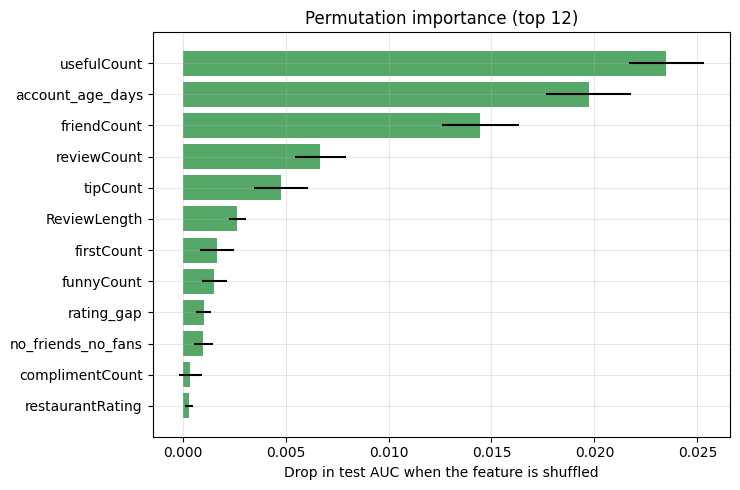

In [18]:
imp = permutation_importance(final_model, test[FINAL_FEATS], y_test, scoring="roc_auc",
                             n_repeats=10, random_state=SEED, n_jobs=1)
imp_df = pd.Series(imp.importances_mean, index=FINAL_FEATS).sort_values()
top = imp_df.tail(12)
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(top.index, top.values, xerr=imp.importances_std[[FINAL_FEATS.index(c) for c in top.index]], color="#55A868")
ax.set_xlabel("Drop in test AUC when the feature is shuffled"); ax.set_title("Permutation importance (top 12)")
plt.tight_layout(); plt.savefig("images/06_importance.png", dpi=150); plt.show()

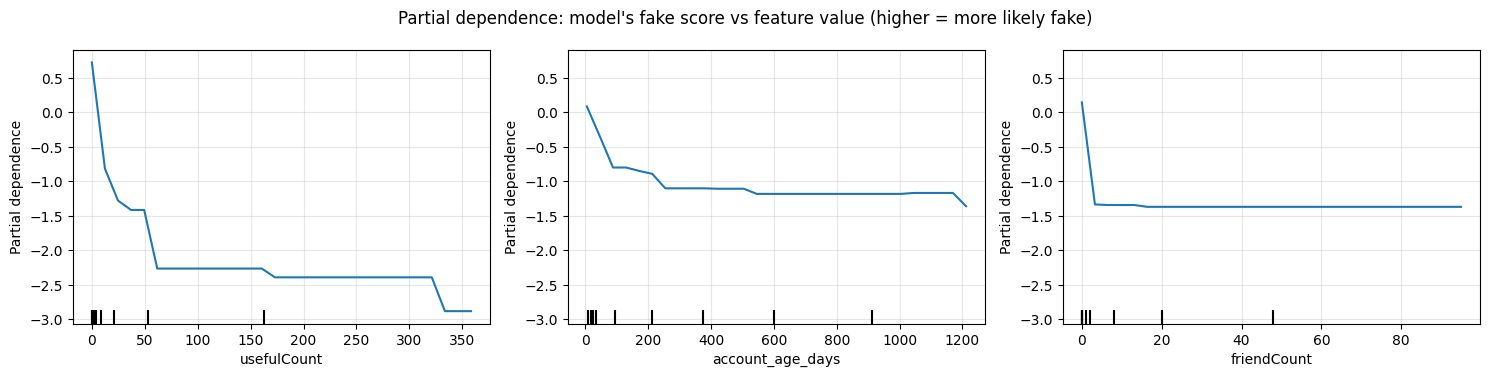

In [19]:
top3 = list(imp_df.tail(3).index[::-1])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
PartialDependenceDisplay.from_estimator(final_model, test[FINAL_FEATS], top3, ax=ax, grid_resolution=30)
plt.suptitle("Partial dependence: model's fake score vs feature value (higher = more likely fake)"); plt.tight_layout()
plt.savefig("images/07_partial_dependence.png", dpi=150); plt.show()

* The model relies mostly on **reviewer-profile features**: votes received, friends, number of reviews and account age.
* The partial-dependence curves show the direction: **more votes, more friends, more reviews and an older account all lower the model's fake score**. This matches the idea of new, isolated, one-off accounts.
* **Caution:** reviewer-activity features are strongly correlated (section 3). When one is shuffled, the others still carry much of the same information, so each individual importance looks smaller than the group's real importance. Read the chart as "this group of features matters", not as a precise ranking inside the group.

## 12. Error analysis
What do the mistakes look like?

In [20]:
err = test.assign(proba=p_test, pred=pred)
err = err[err.pred != err.flagged].copy()
err["error type"] = np.where(err.flagged == 1, "missed fake", "false alarm")
cols = ["reviewCount", "friendCount", "account_age_days", "ReviewLength"]
summary = err.groupby("error type")[cols].median()
summary.loc["ALL test reviews"] = test[cols].median()
display(summary.round(0))
display(err.sort_values("proba").groupby("error type").head(3)[["error type", "proba", "rating", "reviewCount", "friendCount", "account_age_days"]].round(2))

,reviewCount,friendCount,account_age_days,ReviewLength
error type,,,,
false alarm,6.0,0.0,50.0,48.0
missed fake,19.0,3.0,166.0,45.0
ALL test reviews,10.0,1.0,94.0,56.0


,error type,proba,rating,reviewCount,friendCount,account_age_days
238,missed fake,0.00,3.0,86.0,15.0,312.0
109,missed fake,0.01,2.0,137.0,61.0,17.0
140,missed fake,0.02,3.0,61.0,74.0,248.0
987,false alarm,0.50,5.0,4.0,10.0,185.0
949,false alarm,0.51,3.0,21.0,0.0,278.0
1328,false alarm,0.51,5.0,16.0,0.0,27.0


* **Missed fakes** typically come from reviewers with more reviews, more friends and older accounts than the typical flagged review: they have a believable profile.
* **False alarms** are genuine reviews from reviewers with thin profiles (new or low-activity users).
* So the model sometimes confuses "new honest reviewer" with "fake", and "established fake" with "honest". This is why human review of flagged items matters.

## 13. Conclusion

**Final model:** tuned Gradient Boosting on review-level and reviewer-profile features (structured data only, no text analysis).

**Key findings**
1. **Reviewer behaviour is the main fraud signal.**
2. **Model choice matters little;** feature quality matters most.
3. A **leaking feature** (`reviewUsefulCount`) was detected and excluded.
4. The model is strong on new or low-activity accounts but **weak on established reviewers**.
5. The best use is **prioritising moderator review**, not automatic removal.

**Limitations**
* Labels are **Yelp's filter decisions**, not verified fraud, and Yelp's filter itself relies on reviewer behaviour, so the model partly imitates it.
* The data is **~50% fake**; real-world precision would be much lower (section 10).
* About 100 restaurants, mostly reviewed by Chicago-area users, so results may not transfer to other places or domains.
* Some reviewers appear in both train and test; cross-validation was grouped by reviewer, but the final test set still contains some of them.

**Future work:** time-based train/test split, reviewer-restaurant network features and burst detection, probability calibration for realistic fake rates, and (as a separate extension) text analysis.